# BTC Volatility Transformer - Part 4: MCP Agent Data Preparation

**Prerequisites**: Run Parts 1-3 first. You need `volatility_transformer.pt` and `btc_test.csv`.

**This Notebook**: Pre-compute all predictions and signals so the MCP agent can replay through historical data.

---

## Purpose

The Week 4 MCP agent needs to run through historical data to demonstrate the full **Observe → Plan → Act → Learn** loop. Instead of running the transformer model in real-time (which would require PyTorch locally), we:

1. Run the model here in Colab (with GPU)
2. Pre-compute ALL predictions for the test set
3. Save a CSV with everything the agent needs
4. The MCP server loads this CSV and replays it

---

## Output File

We'll create `btc_agent_replay.csv` with columns:
- `datetime`: Timestamp
- `price`: BTC price (close)
- `bid`, `ask`: Estimated bid/ask with spread
- `realized_vol_24h`: Current realized volatility
- `predicted_vol`: Model's prediction
- `vol_surprise`: predicted / realized ratio
- `momentum`: Recent return direction
- `signal`: LONG, SHORT, or NEUTRAL

---
## Section 1: Setup

In [1]:
# =============================================================================
# STEP 1.1: Mount Google Drive
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/btc_volatility_project'
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/btc_volatility_project


In [2]:
# =============================================================================
# STEP 1.2: Imports
# =============================================================================

import numpy as np
import pandas as pd
import json
from datetime import datetime

import torch
import torch.nn as nn

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---
## Section 2: Load Model

Same architecture as Parts 2-3. We need to define the classes before loading weights.

In [35]:
class VolatilityTransformer(nn.Module):
    def __init__(self, num_features, d_model=128, num_heads=4, num_layers=4,
                 d_ff=512, dropout=0.1, max_len=5000):
        super().__init__()
        self.d_model = d_model
        self.input_projection = nn.Linear(num_features, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.output_projection = nn.Linear(d_model, 1)
        self.output_activation = nn.Softplus()
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x, mask=None):
        x = self.input_projection(x)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x, mask)
        x = self.final_norm(x)
        x = x[:, -1, :]
        output = self.output_projection(x)
        output = self.output_activation(output)
        return output.squeeze(-1)

print("✓ Model architecture updated with Softplus")

✓ Model architecture updated with Softplus


In [41]:
checkpoint = torch.load(f'{DATA_DIR}/volatility_transformer.pt', map_location=device, weights_only=False)
model_config = checkpoint['model_config']
model = VolatilityTransformer(
    num_features=model_config['num_features'],
    d_model=model_config['d_model'],
    num_heads=model_config['num_heads'],
    num_layers=model_config['num_layers'],
    d_ff=model_config['d_ff'],
    dropout=model_config['dropout']
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
SEQ_LEN = model_config['seq_len']
FEATURE_COLS = model_config['feature_columns']
print(f"✓ Model re-loaded")

✓ Model re-loaded


---
## Section 3: Load Data

In [5]:
# =============================================================================
# STEP 3.1: Load test data and metadata
# =============================================================================

# Load metadata for normalization stats
with open(f'{DATA_DIR}/btc_metadata.json', 'r') as f:
    metadata = json.load(f)

# Load test data
test_df = pd.read_csv(f'{DATA_DIR}/btc_test.csv')
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

print(f"✓ Test data loaded: {len(test_df):,} rows")
print(f"  Date range: {test_df['datetime'].min()} to {test_df['datetime'].max()}")
print(f"  Columns: {list(test_df.columns)}")

✓ Test data loaded: 6,856 rows
  Date range: 2025-06-15 07:00:00 to 2026-03-28 00:00:00
  Columns: ['datetime', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'log_return', 'abs_return', 'hl_range', 'hl_log_range', 'volume_change', 'volume_ma24', 'volume_ratio', 'trade_count_ma24', 'trade_intensity', 'vwap_deviation', 'realized_vol_6h', 'realized_vol_12h', 'realized_vol_24h', 'realized_vol_48h', 'realized_vol_168h', 'hour', 'day_of_week', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'spread_bps', 'spread_pct', 'estimated_bid', 'estimated_ask', 'target_vol_24h']


In [6]:
# =============================================================================
# STEP 3.2: Show sample data
# =============================================================================

print("Sample of test data:")
test_df.head()

Sample of test data:


,datetime,open,high,low,close,volume,trade_count,vwap,log_return,abs_return,...,day_of_week,hour_sin,hour_cos,dow_sin,dow_cos,spread_bps,spread_pct,estimated_bid,estimated_ask,target_vol_24h
0,2025-06-15 07:00:00,105605.617,105618.570,105278.9770,105468.6315,0.008435,40.0,105425.079848,-0.065347,-0.707120,...,6,1.366348,-0.365714,-1.103136,0.881616,8.219848,0.082198,105425.284692,105511.978308,0.002544
1,2025-06-15 08:00:00,105531.533,105603.374,105153.6360,105216.6400,0.070546,62.0,105244.423208,-0.350271,-0.344397,...,6,1.225056,-0.706756,-1.103136,0.881616,9.274400,0.092744,105167.848940,105265.431060,0.002468
2,2025-06-15 09:00:00,105169.000,105285.950,104896.2790,104976.9285,0.009133,57.0,104985.788993,-0.334073,-0.365018,...,6,1.000292,-0.999615,-1.103136,0.881616,8.711968,0.087120,104931.200718,105022.656282,0.002459
3,2025-06-15 10:00:00,105043.620,105271.080,104976.9285,105156.8600,0.008631,54.0,105102.852430,0.247389,-0.470364,...,6,0.707373,-1.224333,-1.103136,0.881616,7.797264,0.077973,105115.863210,105197.856790,0.002493
4,2025-06-15 11:00:00,105224.000,105250.681,104926.4270,105009.0210,0.009558,73.0,105082.469133,-0.206816,-0.527023,...,6,0.366263,-1.365597,-1.103136,0.881616,8.087868,0.080879,104966.556045,105051.485955,0.002454


---
## Section 4: Generate Predictions

Run the transformer model on ALL test data to pre-compute predictions.

In [7]:
# =============================================================================
# STEP 4.1: Prediction function
# =============================================================================

def generate_predictions(model, df, feature_cols, seq_len, device, batch_size=256):
    """
    Generate predictions for all valid sequences in the dataframe.
    Returns predictions aligned with the dataframe (NaN for first seq_len-1 rows).
    """
    model.eval()
    features = df[feature_cols].values.astype(np.float32)
    n_sequences = len(df) - seq_len + 1

    predictions = []

    with torch.no_grad():
        for start_idx in range(0, n_sequences, batch_size):
            end_idx = min(start_idx + batch_size, n_sequences)

            # Create batch of sequences
            batch_sequences = []
            for i in range(start_idx, end_idx):
                seq = features[i:i + seq_len]
                batch_sequences.append(seq)

            # Convert to tensor
            X_batch = torch.tensor(np.array(batch_sequences)).to(device)

            # Predict
            preds = model(X_batch).cpu().numpy()
            predictions.extend(preds)

            # Progress
            if start_idx % 1000 == 0:
                print(f"  Processed {start_idx:,} / {n_sequences:,} sequences...")

    # Pad with NaN for alignment (first seq_len-1 rows have no prediction)
    aligned_predictions = np.full(len(df), np.nan)
    aligned_predictions[seq_len-1:] = predictions

    return aligned_predictions

print("✓ Prediction function defined")

✓ Prediction function defined


In [42]:
print("Generating predictions...")
test_df['predicted_vol'] = generate_predictions(model, test_df, FEATURE_COLS, SEQ_LEN, device)
print(f"\n✓ New predictions generated")

Generating predictions...
  Processed 0 / 6,793 sequences...

✓ New predictions generated


---
## Section 5: Compute Signals

Apply the Volatility Surprise Momentum strategy to generate trading signals.

In [43]:
vol_mean = metadata['feature_stats']['realized_vol_24h']['mean']
vol_std = metadata['feature_stats']['realized_vol_24h']['std']
return_mean = metadata['feature_stats']['log_return']['mean']
return_std = metadata['feature_stats']['log_return']['std']
test_df['realized_vol_actual'] = test_df['realized_vol_24h'] * vol_std + vol_mean
test_df['predicted_vol_actual'] = test_df['predicted_vol']
test_df['log_return_raw'] = test_df['log_return'] * return_std + return_mean
print(f"✓ Features corrected")

✓ Features corrected


In [44]:
test_df['vol_surprise'] = test_df['predicted_vol_actual'] / test_df['realized_vol_actual']
test_df['vol_surprise'] = test_df['vol_surprise'].replace([np.inf, -np.inf], np.nan).fillna(1.0)
print("Corrected Volatility surprise statistics:")
print(f"  Mean: {test_df['vol_surprise'].mean():.4f}")

Corrected Volatility surprise statistics:
  Mean: 1.4230


In [11]:
# =============================================================================
# STEP 5.3: Compute momentum
# =============================================================================

MOMENTUM_LOOKBACK = 6  # hours

# Compute rolling return over lookback period
test_df['momentum'] = test_df['log_return_raw'].rolling(window=MOMENTUM_LOOKBACK).sum()

print(f"Momentum ({MOMENTUM_LOOKBACK}h) statistics:")
print(f"  Mean:   {test_df['momentum'].mean()*100:.3f}%")
print(f"  Std:    {test_df['momentum'].std()*100:.3f}%")

Momentum (6h) statistics:
  Mean:   -0.041%
  Std:    1.156%


In [50]:
# =============================================================================
# STEP 5.4: Generate trading signals (Reverting to 1.1 threshold)
# =============================================================================

VOL_SURPRISE_UPPER = 1.10 # Reverting to original threshold since predictions are now correct

def compute_signal(row):
    if pd.isna(row['vol_surprise']) or pd.isna(row['momentum']):
        return 'NEUTRAL'

    if row['vol_surprise'] > VOL_SURPRISE_UPPER:
        return 'LONG' if row['momentum'] > 0 else 'SHORT'

    return 'NEUTRAL'

test_df['signal'] = test_df.apply(compute_signal, axis=1)

print(f"\nSignal distribution (Threshold: {VOL_SURPRISE_UPPER}):")
print(test_df['signal'].value_counts())


Signal distribution (Threshold: 1.1):
signal
SHORT      2362
LONG       2332
NEUTRAL    2162
Name: count, dtype: int64


--- ## Section 6: Prepare Agent Replay Data

Create the final CSV with all information the MCP agent needs.

In [25]:
# =============================================================================
# STEP 6.1: Compute bid/ask prices
# =============================================================================

# Estimate spread based on volatility (same as Part 1)
# Higher volatility = wider spread
BASE_SPREAD_BPS = 2  # 2 basis points base
VOL_MULTIPLIER = 0.1  # Spread widens with vol

# Use hl_range as volatility proxy if available, otherwise use realized vol
if 'hl_range' in test_df.columns:
    hl_mean = metadata['feature_stats']['hl_range']['mean']
    hl_std = metadata['feature_stats']['hl_range']['std']
    test_df['hl_range_raw'] = test_df['hl_range'] * hl_std + hl_mean
    test_df['spread_pct'] = (BASE_SPREAD_BPS / 10000) + (VOL_MULTIPLIER * test_df['hl_range_raw'])
else:
    test_df['spread_pct'] = (BASE_SPREAD_BPS / 10000) + (VOL_MULTIPLIER * test_df['realized_vol_raw'] / 100)

# Compute bid and ask
test_df['bid'] = test_df['close'] * (1 - test_df['spread_pct'] / 2)
test_df['ask'] = test_df['close'] * (1 + test_df['spread_pct'] / 2)
test_df['spread_bps'] = test_df['spread_pct'] * 10000

print(f"Spread statistics:")
print(f"  Mean spread: {test_df['spread_bps'].mean():.1f} bps")
print(f"  Spread range: [{test_df['spread_bps'].min():.1f}, {test_df['spread_bps'].max():.1f}] bps")

Spread statistics:
  Mean spread: 10.3 bps
  Spread range: [2.4, 127.4] bps


In [51]:
agent_df = test_df[[
    'datetime', 'close', 'bid', 'ask', 'realized_vol_actual', 'predicted_vol_actual', 'vol_surprise', 'momentum', 'signal', 'spread_bps'
]].copy()
agent_df = agent_df.rename(columns={'close': 'price', 'realized_vol_actual': 'realized_vol', 'predicted_vol_actual': 'predicted_vol'})
agent_df = agent_df.dropna(subset=['predicted_vol'])
# Filter signal counts for metadata
signal_counts = agent_df['signal'].value_counts().to_dict()
print(f"✓ Agent replay data updated with 1.1 threshold")

✓ Agent replay data updated with 1.1 threshold


In [27]:
# =============================================================================
# STEP 6.3: Preview the data
# =============================================================================

print("Preview of agent replay data:")
print("\nFirst 5 rows:")
display(agent_df.head())

print("\nSample of LONG signals:")
display(agent_df[agent_df['signal'] == 'LONG'].head())

print("\nSample of SHORT signals:")
display(agent_df[agent_df['signal'] == 'SHORT'].head())

Preview of agent replay data:

First 5 rows:


,datetime,price,bid,ask,realized_vol,predicted_vol,vol_surprise,momentum,signal,spread_bps
63,2025-06-17 22:00:00,104310.9000,104274.075660,104347.724340,1.003451,0.986319,0.982927,0.006364,NEUTRAL,7.060497
64,2025-06-17 23:00:00,104604.7655,104572.811773,104636.719227,1.003162,0.986371,0.983262,0.007043,NEUTRAL,6.109421
65,2025-06-18 00:00:00,104865.5760,104832.363317,104898.788683,1.003034,0.986342,0.983358,0.004098,NEUTRAL,6.334335
66,2025-06-18 01:00:00,104822.8350,104787.160542,104858.509459,1.003036,0.986279,0.983294,0.001064,NEUTRAL,6.806620
67,2025-06-18 02:00:00,104932.9125,104903.528709,104962.296291,1.002950,0.986196,0.983295,0.005035,NEUTRAL,5.600491



Sample of LONG signals:


,datetime,price,bid,ask,realized_vol,predicted_vol,vol_surprise,momentum,signal,spread_bps



Sample of SHORT signals:


,datetime,price,bid,ask,realized_vol,predicted_vol,vol_surprise,momentum,signal,spread_bps


In [28]:
# =============================================================================
# STEP 6.4: Data validation
# =============================================================================

print("Data validation:")
print(f"  Missing values: {agent_df.isna().sum().sum()}")
print(f"  Price range: ${agent_df['price'].min():,.2f} - ${agent_df['price'].max():,.2f}")
print(f"  Vol surprise range: {agent_df['vol_surprise'].min():.3f} - {agent_df['vol_surprise'].max():.3f}")
print(f"  Signals: {agent_df['signal'].value_counts().to_dict()}")

# Check for any issues
assert agent_df['price'].min() > 0, "Negative prices found!"
assert agent_df['bid'].min() > 0, "Negative bids found!"
assert (agent_df['bid'] <= agent_df['price']).all(), "Bid > Price found!"
assert (agent_df['ask'] >= agent_df['price']).all(), "Ask < Price found!"

print("\n✓ All validation checks passed")

Data validation:
  Missing values: 0
  Price range: $62,786.26 - $126,117.15
  Vol surprise range: 0.973 - 0.986
  Signals: {'NEUTRAL': 6793}

✓ All validation checks passed


--- ## Section 7: Save for MCP Agent

In [52]:
output_path = f'{DATA_DIR}/btc_agent_replay.csv'
agent_df.to_csv(output_path, index=False)
print(f"✓ Final corrected CSV saved to: {output_path}")

✓ Final corrected CSV saved to: /content/drive/MyDrive/btc_volatility_project/btc_agent_replay.csv


In [30]:
# =============================================================================
# STEP 7.2: Also save metadata for the agent
# =============================================================================

agent_metadata = {
    'created': datetime.now().isoformat(),
    'source_model': 'volatility_transformer.pt',
    'seq_len': SEQ_LEN,
    'n_rows': len(agent_df),
    'date_range': {
        'start': str(agent_df['datetime'].min()),
        'end': str(agent_df['datetime'].max()),
    },
    'strategy_params': {
        'vol_surprise_threshold': VOL_SURPRISE_UPPER,
        'momentum_lookback': MOMENTUM_LOOKBACK,
    },
    'signal_counts': agent_df['signal'].value_counts().to_dict(),
    'price_range': {
        'min': float(agent_df['price'].min()),
        'max': float(agent_df['price'].max()),
    },
}

metadata_path = f'{DATA_DIR}/btc_agent_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(agent_metadata, f, indent=2)

print(f"✓ Metadata saved to: {metadata_path}")
print(json.dumps(agent_metadata, indent=2))

✓ Metadata saved to: /content/drive/MyDrive/btc_volatility_project/btc_agent_metadata.json
{
  "created": "2026-03-31T10:09:51.193120",
  "source_model": "volatility_transformer.pt",
  "seq_len": 64,
  "n_rows": 6793,
  "date_range": {
    "start": "2025-06-17 22:00:00",
    "end": "2026-03-28 00:00:00"
  },
  "strategy_params": {
    "vol_surprise_threshold": 1.005,
    "momentum_lookback": 6
  },
  "signal_counts": {
    "NEUTRAL": 6793
  },
  "price_range": {
    "min": 62786.261,
    "max": 126117.15
  }
}


--- ## Section 8: Download Instructions

In [48]:
print("="*60)
print("PART 4 COMPLETE: MCP AGENT DATA PREPARED")
print("="*60)
print(f"\n📊 Data summary:")
print(f"   • {len(agent_df):,} hours of data")
print(f"   • LONG signals:    {(agent_df['signal'] == 'LONG').sum():,}")
print(f"   • SHORT signals:   {(agent_df['signal'] == 'SHORT').sum():,}")
print(f"   • NEUTRAL signals: {(agent_df['signal'] == 'NEUTRAL').sum():,}")

PART 4 COMPLETE: MCP AGENT DATA PREPARED

📊 Data summary:
   • 6,793 hours of data
   • LONG signals:    2,592
   • SHORT signals:   2,665
   • NEUTRAL signals: 1,536


Detailed Volatility Surprise Statistics:
  Min:    0.4038
  10%:    0.8078
  Median: 1.2839
  Mean:   1.4230
  90%:    2.2423
  Max:    5.4404

Counts at different thresholds:
  Over 1.005: 5,257 rows (76.7%)
  Over 1.01: 5,228 rows (76.3%)
  Over 1.05: 4,985 rows (72.7%)
  Over 1.1: 4,694 rows (68.5%)
  Over 1.2: 3,980 rows (58.1%)


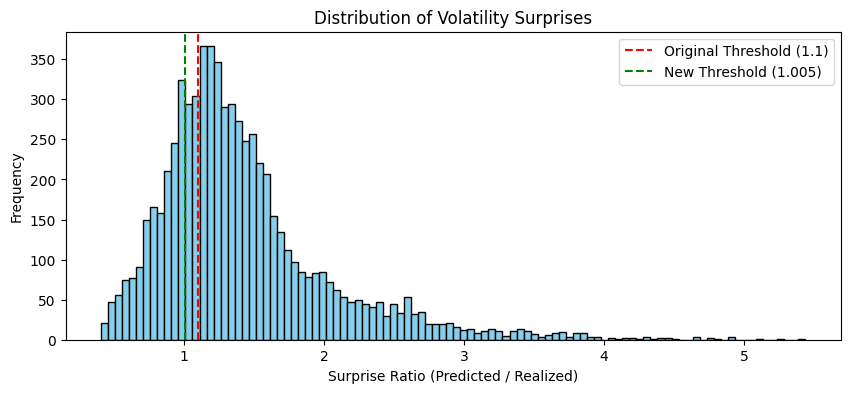

In [49]:
import matplotlib.pyplot as plt

# Analyze the distribution of vol_surprise
surprise_series = test_df['vol_surprise'].dropna()

print("Detailed Volatility Surprise Statistics:")
print(f"  Min:    {surprise_series.min():.4f}")
print(f"  10%:    {surprise_series.quantile(0.1):.4f}")
print(f"  Median: {surprise_series.median():.4f}")
print(f"  Mean:   {surprise_series.mean():.4f}")
print(f"  90%:    {surprise_series.quantile(0.9):.4f}")
print(f"  Max:    {surprise_series.max():.4f}")

# Check counts for different thresholds
print(f"\nCounts at different thresholds:")
for t in [1.005, 1.01, 1.05, 1.1, 1.2]:
    count = (surprise_series > t).sum()
    print(f"  Over {t}: {count:,} rows ({(count/len(surprise_series)*100):.1f}%)")

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(surprise_series, bins=100, color='skyblue', edgecolor='black')
plt.axvline(1.1, color='red', linestyle='--', label='Original Threshold (1.1)')
plt.axvline(1.005, color='green', linestyle='--', label='New Threshold (1.005)')
plt.title('Distribution of Volatility Surprises')
plt.xlabel('Surprise Ratio (Predicted / Realized)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [32]:
# =============================================================================
# STEP 8.2: Download files (optional - can also download from Drive)
# =============================================================================

from google.colab import files

# Uncomment to download directly:
# files.download(output_path)
# files.download(metadata_path)

print("To download files:")
print("  Option 1: Go to Google Drive and download from btc_volatility_project/")
print("  Option 2: Uncomment the lines above and run this cell")

To download files:
  Option 1: Go to Google Drive and download from btc_volatility_project/
  Option 2: Uncomment the lines above and run this cell
